In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve


In [2]:
df = pd.read_csv("C:\\Users\\user\\Documents\\프로젝트\\3차_Job Stress dataset\\main_repo\\DATA\\dataset.csv")

In [3]:
# 직무 스트레스 항목
df['Occupational_Stress_Sum'] = df[['OS1', 'OS2', 'OS3', 'OS4', 'OS5', 'OS6', 'OS7', 'OS8',
                                    'OS9', 'OS10', 'OS11', 'OS12', 'OS13', 'OS14',
                                    'OS15', 'OS16', 'OS17', 'OS18', 'OS19',
                                    'OS20', 'OS21', 'OS22', 'OS23',
                                    'OS24', 'OS25', 'OS26', 'OS27', 'OS28',
                                    'OS29', 'OS30', 'OS31',
                                    'OS32', 'OS33', 'OS34', 'OS35',
                                    'OS36', 'OS37', 'OS38', 'OS39',
                                    'OS40', 'OS41']].sum(axis=1)

# 정규화
scaler = MinMaxScaler()
df['Occupational_Stress_Normalized'] = scaler.fit_transform(df[['Occupational_Stress_Sum']])

# 0.5기준 이진화 
df['Occupational_Stress_Target'] = df['Occupational_Stress_Normalized'].apply(lambda x: 0 if x <= 0.5 else 1)

In [4]:
df.drop(columns=['OS1', 'OS2', 'OS3', 'OS4', 'OS5', 'OS6', 'OS7', 'OS8', 'OS9', 'OS10', 'OS11', 'OS12', 'OS13', 'OS14', 'OS15', 'OS16', 'OS17', 'OS18', 'OS19', 'OS20', 'OS21', 'OS22', 'OS23', 'OS24', 'OS25', 'OS26', 'OS27', 'OS28', 'OS29', 'OS30', 'OS31', 'OS32', 'OS33', 'OS34', 'OS35', 'OS36', 'OS37', 'OS38', 'OS39', 'OS40', 'OS41'], inplace=True)
df = df.drop(columns=['Occupational_Stress_Sum', 'Occupational_Stress_Normalized'])

In [5]:
# 데이터 분할

X = df.drop(['Occupational_Stress_Target'], axis=1)  # Features
y = df['Occupational_Stress_Target']  # Target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify = y, random_state=42)

In [6]:
# 정규화

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [7]:
# 이상치 처리 - 평균값으로 대체
for column in X_train.columns:
    # Calculate IQR
    Q1 = X_train[column].quantile(0.25)
    Q3 = X_train[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Detect outliers
    outliers = X_train[(X_train[column] < lower_bound) | (X_train[column] > upper_bound)]
    
    mean_value = X_train[(X_train[column] >= lower_bound) & (X_train[column] <= upper_bound)][column].mean()
    X_train.loc[(X_train[column] < lower_bound) | (X_train[column] > upper_bound), column] = mean_value

In [8]:
# 두모델의 합집합 변수 선택 (합집합37+추가2=임의로 한듯?)
combined_features = [
    "JS36", "JS23", "JS35", "Household income", "JS33", "JS21", "JS17", "JS11", "JS24",
    "JS26", "JP4", "Sperm quality", "JS5", "JS6", "JS15", "JS4", "JS7", "Educational level",
    "JS20", "JS14", "JS22", "JS29", "JS10", "JS12", "JS2", "JS28", "JS18", "JS25", "JS8",
    "JS31", "JS30", "JP6", "JS3", "JS32", "JS16", "JS13", "JS19", "JS1", "JP5"
]



# 훈련데이터/테스트 데이터에 변수 적용
X_train_selected = X_train[combined_features]
X_test_selected = X_test[combined_features]

X_train = X_train_selected
X_test = X_test_selected



In [9]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

In [10]:
! pip install xgboost

In [11]:
! pip install lightgbm

In [12]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [13]:
# 하이퍼파라미터 정의
param_distributions = {
    'GaussianNB': {},  
    'DecisionTreeClassifier': {
        'max_depth': [None, 10, 20, 30, 40, 50],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    'RandomForestClassifier': {
        'n_estimators': [100, 200, 300],
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    'AdaBoostClassifier': {
        'n_estimators': [50, 100, 150],
        'learning_rate': [0.01, 0.1, 1.0]
    },
    'LGBMClassifier': {
        'num_leaves': [31, 62, 127],
        'learning_rate': [0.01, 0.1, 0.5],
        'n_estimators': [100, 200, 300]
    },
    'XGBClassifier': {
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.01, 0.1, 0.5],
        'max_depth': [3, 6, 9]
    },
    'LinearRegression': {},  
    'LogisticRegression': {
        'C': np.logspace(-4, 4, 20),
        'solver': ['liblinear', 'lbfgs']
    },
    'SVC': {
        'C': [0.1, 1, 10],
        'kernel': ['linear', 'rbf']
    },
    'KNeighborsClassifier': {
        'n_neighbors': [3, 5, 7, 9],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan']
    }
}

# 모델링
models = {
    'GaussianNB': GaussianNB(),
    'DecisionTreeClassifier': DecisionTreeClassifier(),
    'RandomForestClassifier': RandomForestClassifier(),
    'AdaBoostClassifier': AdaBoostClassifier(),
    'LGBMClassifier': LGBMClassifier(random_state=42),
    'XGBClassifier': XGBClassifier(random_state=42),
    'LinearRegression': LinearRegression(),
    'LogisticRegression': LogisticRegression(),
    'SVC': SVC(),
    'KNeighborsClassifier': KNeighborsClassifier()
}

best_params = {}

for model_name, model in models.items():
    print(f"Running RandomizedSearchCV for {model_name}")
    clf = RandomizedSearchCV(model, param_distributions[model_name], n_iter=10, cv=5, verbose=2, random_state=42, n_jobs=-1)
    clf.fit(X_train, y_train)
    best_params[model_name] = clf.best_params_
    print(f"Best parameters for {model_name}: {clf.best_params_}")

Running RandomizedSearchCV for GaussianNB
Fitting 5 folds for each of 1 candidates, totalling 5 fits


c:\Users\user\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 1 is smaller than n_iter=10. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best parameters for GaussianNB: {}
Running RandomizedSearchCV for DecisionTreeClassifier
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best parameters for DecisionTreeClassifier: {'min_samples_split': 10, 'min_samples_leaf': 2, 'max_depth': 30}
Running RandomizedSearchCV for RandomForestClassifier
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best parameters for RandomForestClassifier: {'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': 20}
Running RandomizedSearchCV for AdaBoostClassifier
Fitting 5 folds for each of 9 candidates, totalling 45 fits


c:\Users\user\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 9 is smaller than n_iter=10. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
c:\Users\user\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


Best parameters for AdaBoostClassifier: {'n_estimators': 50, 'learning_rate': 0.1}
Running RandomizedSearchCV for LGBMClassifier
Fitting 5 folds for each of 10 candidates, totalling 50 fits


c:\Users\user\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] 지정된 파일을 찾을 수 없습니다
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\user\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\user\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\user\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\user\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
      

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 157, number of negative: 90
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000213 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 216
[LightGBM] [Info] Number of data points in the train set: 247, number of used features: 39
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.635628 -> initscore=0.556436
[LightGBM] [Info] Start training from score 0.556436
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

c:\Users\user\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 1 is smaller than n_iter=10. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
c:\Users\user\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 6 is smaller than n_iter=10. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best parameters for SVC: {'kernel': 'linear', 'C': 0.1}
Running RandomizedSearchCV for KNeighborsClassifier
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best parameters for KNeighborsClassifier: {'weights': 'uniform', 'n_neighbors': 5, 'metric': 'euclidean'}


Classification Report for GaussianNB:
              precision    recall  f1-score   support

           0     0.6087    0.6087    0.6087        23
           1     0.7692    0.7692    0.7692        39

    accuracy                         0.7097        62
   macro avg     0.6890    0.6890    0.6890        62
weighted avg     0.7097    0.7097    0.7097        62



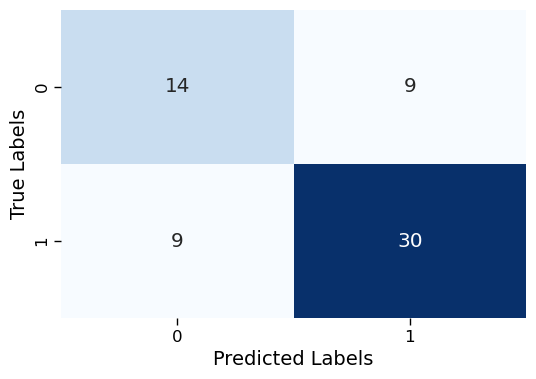

ROC-AUC Score for GaussianNB: 0.7469


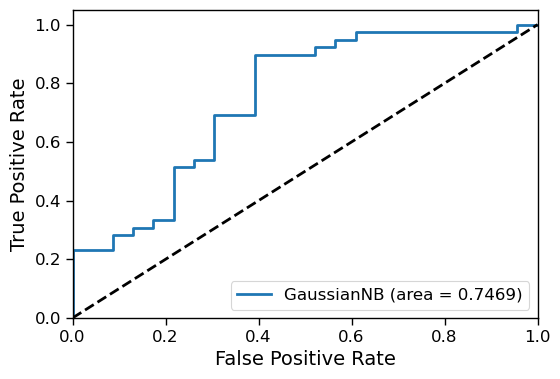

Classification Report for DecisionTreeClassifier:
              precision    recall  f1-score   support

           0     0.7059    0.5217    0.6000        23
           1     0.7556    0.8718    0.8095        39

    accuracy                         0.7419        62
   macro avg     0.7307    0.6968    0.7048        62
weighted avg     0.7371    0.7419    0.7318        62



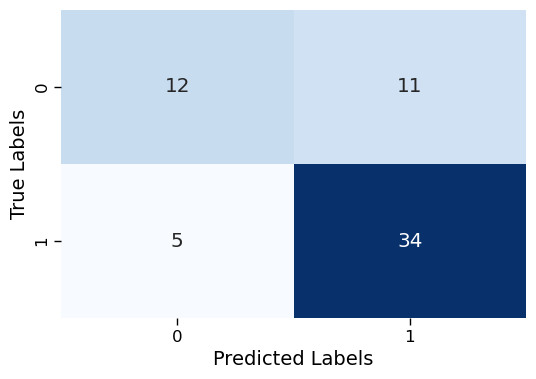

ROC-AUC Score for DecisionTreeClassifier: 0.7358


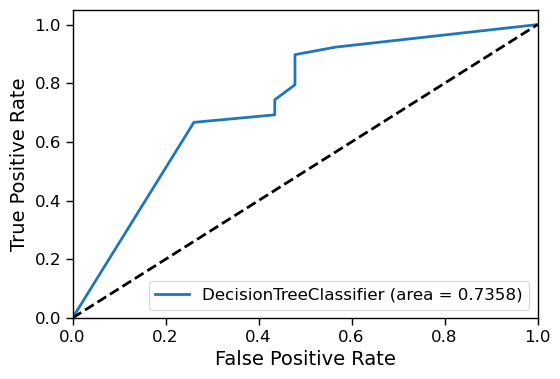

Classification Report for RandomForestClassifier:
              precision    recall  f1-score   support

           0     0.9474    0.7826    0.8571        23
           1     0.8837    0.9744    0.9268        39

    accuracy                         0.9032        62
   macro avg     0.9155    0.8785    0.8920        62
weighted avg     0.9073    0.9032    0.9010        62



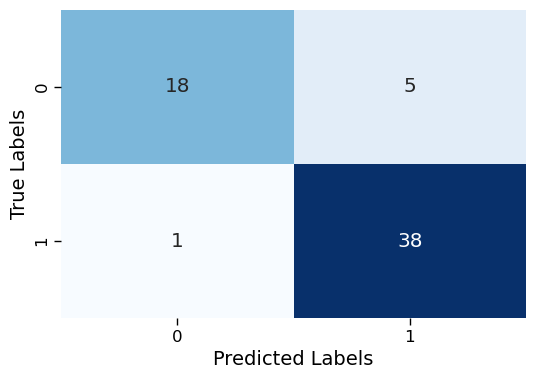

ROC-AUC Score for RandomForestClassifier: 0.8907


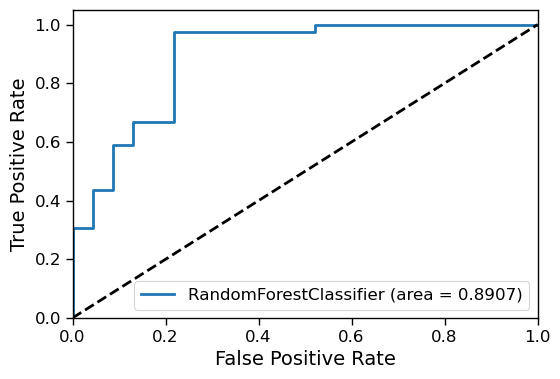

Classification Report for AdaBoostClassifier:
              precision    recall  f1-score   support

           0     0.8667    0.5652    0.6842        23
           1     0.7872    0.9487    0.8605        39

    accuracy                         0.8065        62
   macro avg     0.8270    0.7570    0.7723        62
weighted avg     0.8167    0.8065    0.7951        62



c:\Users\user\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


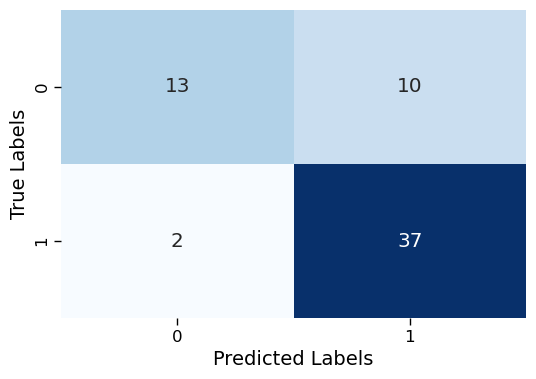

ROC-AUC Score for AdaBoostClassifier: 0.8774


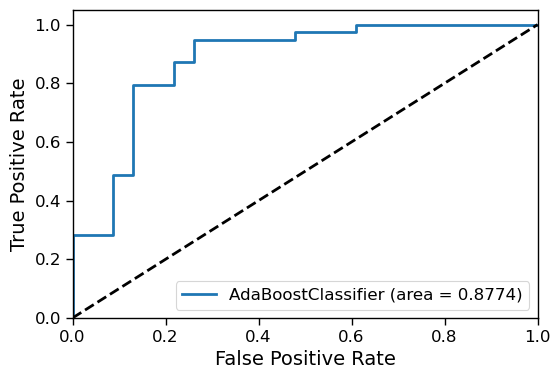

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 157, number of negative: 90
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000185 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 216
[LightGBM] [Info] Number of data points in the train set: 247, number of used features: 39
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.635628 -> initscore=0.556436
[LightGBM] [Info] Start training from score 0.556436
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

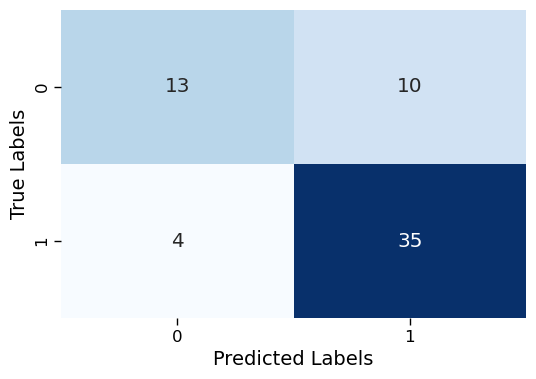

ROC-AUC Score for LGBMClassifier: 0.8729


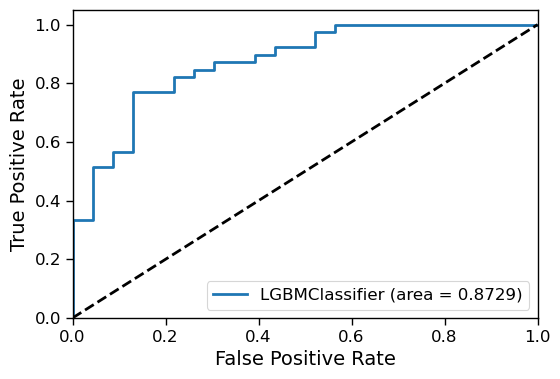

Classification Report for XGBClassifier:
              precision    recall  f1-score   support

           0     0.7391    0.7391    0.7391        23
           1     0.8462    0.8462    0.8462        39

    accuracy                         0.8065        62
   macro avg     0.7926    0.7926    0.7926        62
weighted avg     0.8065    0.8065    0.8065        62



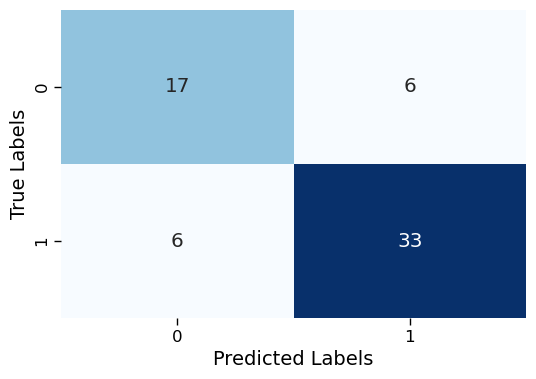

ROC-AUC Score for XGBClassifier: 0.8696


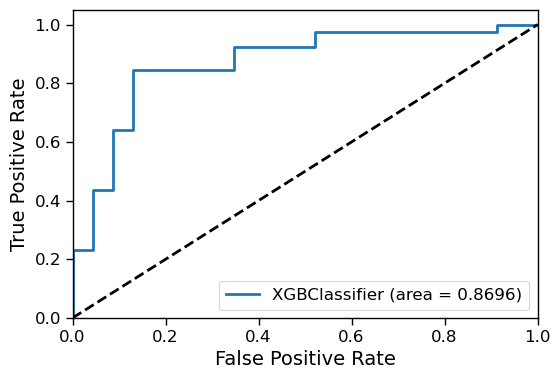

Classification Report for LinearRegression:
              precision    recall  f1-score   support

           0     0.7500    0.6522    0.6977        23
           1     0.8095    0.8718    0.8395        39

    accuracy                         0.7903        62
   macro avg     0.7798    0.7620    0.7686        62
weighted avg     0.7874    0.7903    0.7869        62



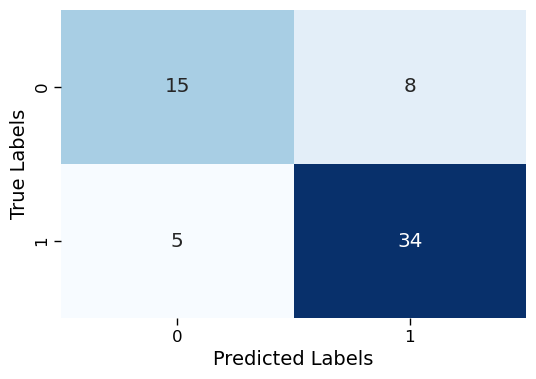

ROC-AUC Score for LinearRegression: 0.7848


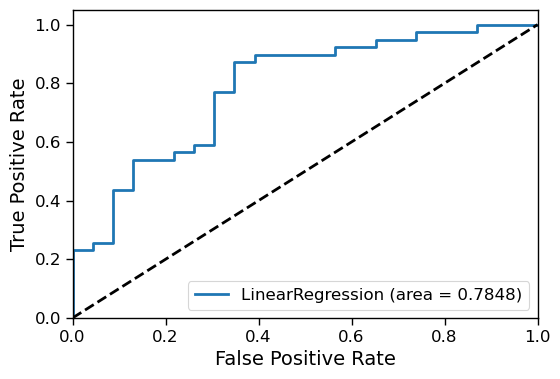

Classification Report for LogisticRegression:
              precision    recall  f1-score   support

           0     0.9444    0.7391    0.8293        23
           1     0.8636    0.9744    0.9157        39

    accuracy                         0.8871        62
   macro avg     0.9040    0.8567    0.8725        62
weighted avg     0.8936    0.8871    0.8836        62



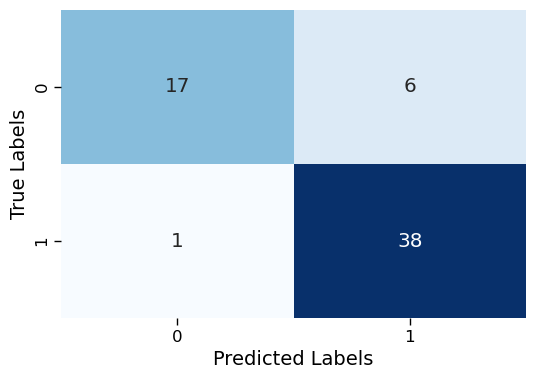

ROC-AUC Score for LogisticRegression: 0.8629


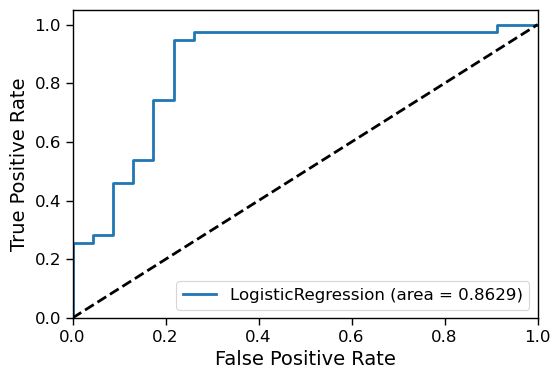

Classification Report for SVC:
              precision    recall  f1-score   support

           0     0.9474    0.7826    0.8571        23
           1     0.8837    0.9744    0.9268        39

    accuracy                         0.9032        62
   macro avg     0.9155    0.8785    0.8920        62
weighted avg     0.9073    0.9032    0.9010        62



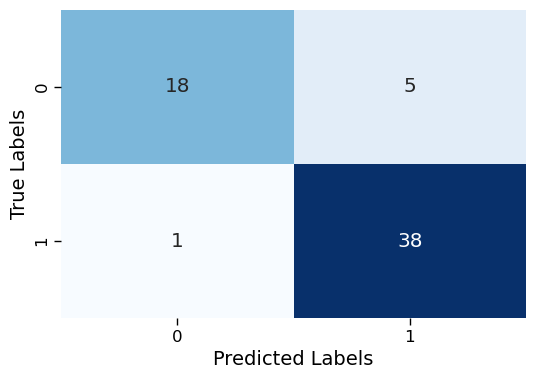

ROC-AUC Score for SVC: 0.8729


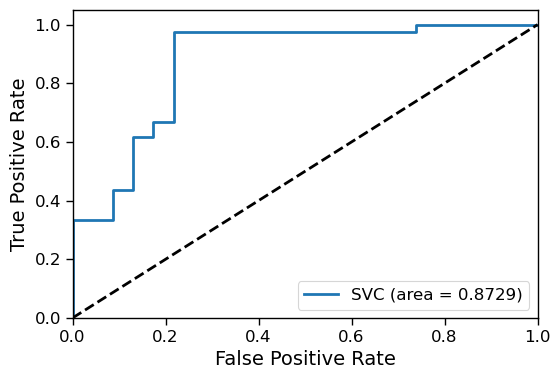

Classification Report for KNeighborsClassifier:
              precision    recall  f1-score   support

           0     0.8125    0.5652    0.6667        23
           1     0.7826    0.9231    0.8471        39

    accuracy                         0.7903        62
   macro avg     0.7976    0.7441    0.7569        62
weighted avg     0.7937    0.7903    0.7801        62



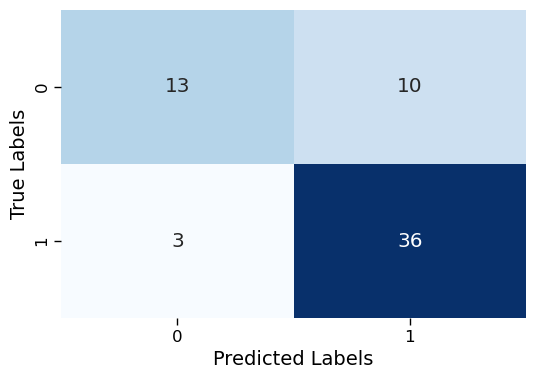

ROC-AUC Score for KNeighborsClassifier: 0.7692


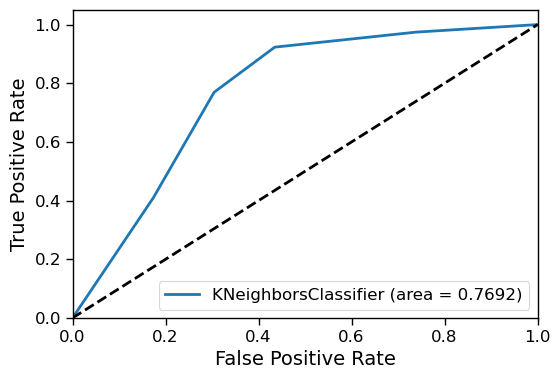

In [16]:
# 플롯 설정
sns.set_context("paper", font_scale=1.5)
plt.rcParams['figure.figsize'] = [6, 4] 

for model_name, model in models.items():
    # 최적의 매개변수 
    optimized_model = model.set_params(**best_params[model_name])

    # 모델에 적용
    optimized_model.fit(X_train, y_train)

    # 테스트 데이터 예측
    y_pred = optimized_model.predict(X_test)

    # 선형회귀의 경우, 이진으로 변환
    if model_name == 'LinearRegression':
        y_pred_binary = (y_pred > 0.5).astype(int)
        y_proba = y_pred  
    else:
        #  ROC-AUC
        if hasattr(optimized_model, "predict_proba"):
            y_proba = optimized_model.predict_proba(X_test)[:, 1]
        elif hasattr(optimized_model, "decision_function"):
            y_proba = optimized_model.decision_function(X_test)
        else:
            y_proba = y_pred  
        y_pred_binary = y_pred

    # 분류 성능 보고서 시각화
    print(f"Classification Report for {model_name}:")
    print(classification_report(y_test, y_pred_binary, digits=4))

    # 혼동행렬 시각화
    cm = confusion_matrix(y_test, y_pred_binary)
    plt.figure(figsize=(6, 4))  
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    # plt.title(f'Confusion Matrix for {model_name}', fontsize=16)
    plt.xlabel('Predicted Labels', fontsize=14)
    plt.ylabel('True Labels', fontsize=14)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.show()

    # ROC-AUC score 계산
    roc_auc = roc_auc_score(y_test, y_proba)
    print(f"ROC-AUC Score for {model_name}: {roc_auc:.4f}")

    # ROC curve 시각화
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.figure(figsize=(6, 4))  
    plt.plot(fpr, tpr, label=f'{model_name} (area = {roc_auc:.4f})', linewidth=2)
    plt.plot([0, 1], [0, 1], 'k--', linewidth=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=14)
    plt.ylabel('True Positive Rate', fontsize=14)
    # plt.title(f'Receiver Operating Characteristic for {model_name}', fontsize=16)
    plt.legend(loc="lower right", fontsize=12)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.show()

# Ensemble Model Creation

Training hard voting classifier
Training soft voting classifier

Classification Report for Hard Voting:
              precision    recall  f1-score   support

           0     0.9474    0.7826    0.8571        23
           1     0.8837    0.9744    0.9268        39

    accuracy                         0.9032        62
   macro avg     0.9155    0.8785    0.8920        62
weighted avg     0.9073    0.9032    0.9010        62



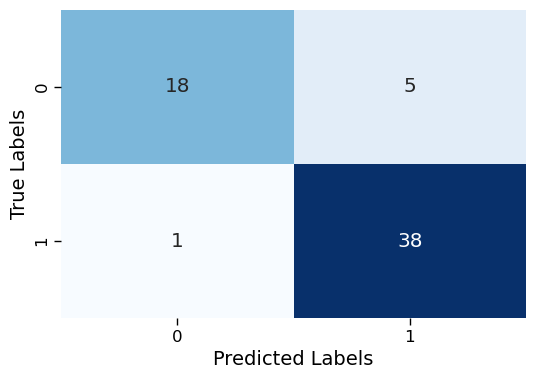

ROC-AUC Score for Hard Voting: 0.8785


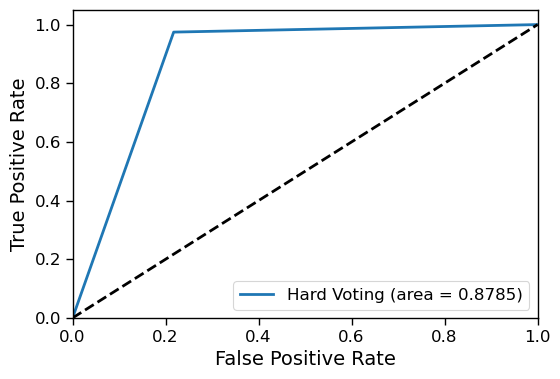


Classification Report for Soft Voting:
              precision    recall  f1-score   support

           0     0.9444    0.7391    0.8293        23
           1     0.8636    0.9744    0.9157        39

    accuracy                         0.8871        62
   macro avg     0.9040    0.8567    0.8725        62
weighted avg     0.8936    0.8871    0.8836        62



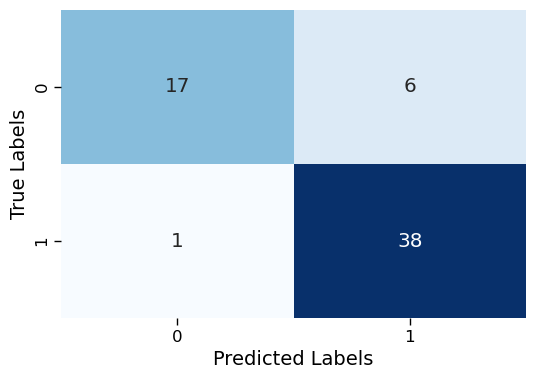

ROC-AUC Score for Soft Voting: 0.8673


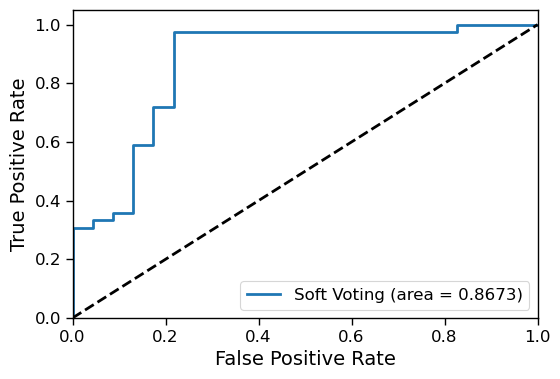

In [15]:
from sklearn.ensemble import VotingClassifier

# 플롯 설정
sns.set_context("paper", font_scale=1.5)
plt.rcParams['figure.figsize'] = [6, 4]  # Set default figure size

# best_params dict에 모든 모델의 최적 매개변수 포함되어있다고 가정
rf_best = RandomForestClassifier(**best_params['RandomForestClassifier'])
ada_best = AdaBoostClassifier(**best_params['AdaBoostClassifier'])
xgb_best = XGBClassifier(**best_params['XGBClassifier'])
lr_best = LogisticRegression(**best_params['LogisticRegression'])
svc_best = SVC(**best_params['SVC'], probability=True)  # 소프트투표에 확률 활성화

# hard voting 위한 VotingClassifier 생성
voting_clf_hard = VotingClassifier(
    estimators=[
        # ('rf', rf_best),
        # ('ada', ada_best),
        # ('xgb', xgb_best),
        ('lr', lr_best),
        ('svc', svc_best)
    ],
    voting='hard'
)

# soft voting 위한 VotingClassifier 생성
voting_clf_soft = VotingClassifier(
    estimators=[
        # ('rf', rf_best),
        # ('ada', ada_best),
        # ('xgb', xgb_best),
        ('lr', lr_best),
        ('svc', svc_best)
    ],
    voting='soft'
)

# hard voting classifier 훈련
print("Training hard voting classifier")
voting_clf_hard.fit(X_train, y_train)

# soft voting classifier 훈련
print("Training soft voting classifier")
voting_clf_soft.fit(X_train, y_train)

# 두 분류 평가
for clf, label in zip([voting_clf_hard, voting_clf_soft], ['Hard Voting', 'Soft Voting']):
    y_pred = clf.predict(X_test)

    # 소프트 투표의 경우 ROC-AUC에 대한 확률을 계산
    # 하드 투표의 경우 예측을 확률로 사용
    if label == 'Soft Voting':
        y_proba = clf.predict_proba(X_test)[:, 1]
    else:
        y_proba = clf.predict(X_test)  

    print(f"\nClassification Report for {label}:")
    print(classification_report(y_test, y_pred, digits=4))

    # 혼동행렬 시각화
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))  
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    # plt.title(f'Confusion Matrix for {label}', fontsize=16)
    plt.xlabel('Predicted Labels', fontsize=14)
    plt.ylabel('True Labels', fontsize=14)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.show()

    # ROC-AUC score 계산
    roc_auc = roc_auc_score(y_test, y_proba)
    print(f"ROC-AUC Score for {label}: {roc_auc:.4f}")

    # ROC curve 시각화
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.figure(figsize=(6, 4))  
    plt.plot(fpr, tpr, label=f'{label} (area = {roc_auc:.4f})', linewidth=2)
    plt.plot([0, 1], [0, 1], 'k--', linewidth=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=14)
    plt.ylabel('True Positive Rate', fontsize=14)
    # plt.title(f'Receiver Operating Characteristic for {label}', fontsize=16)
    plt.legend(loc="lower right", fontsize=12)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.show()

# Explainable AI

In [17]:
!pip install shap

  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
   ---------------------------------------- 0.0/548.0 kB ? eta -:--:--
   ---------------------------------------- 548.0/548.0 kB 9.2 MB/s eta 0:00:00
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)


In [18]:
!pip install lime

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283840 sha256=82dbf1fcb9c402a1ec1c6ff7a1f578747b6202dd89c5438d85363ed7d34c6547
  Stored in directory: c:\users\user\appdata\local\pip\cache\wheels\e7\5d\0e\4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [19]:
X_train.columns

Index(['JS36', 'JS23', 'JS35', 'Household income', 'JS33', 'JS21', 'JS17',
       'JS11', 'JS24', 'JS26', 'JP4', 'Sperm quality', 'JS5', 'JS6', 'JS15',
       'JS4', 'JS7', 'Educational level', 'JS20', 'JS14', 'JS22', 'JS29',
       'JS10', 'JS12', 'JS2', 'JS28', 'JS18', 'JS25', 'JS8', 'JS31', 'JS30',
       'JP6', 'JS3', 'JS32', 'JS16', 'JS13', 'JS19', 'JS1', 'JP5'],
      dtype='object')

In [20]:
X_test.columns

Index(['JS36', 'JS23', 'JS35', 'Household income', 'JS33', 'JS21', 'JS17',
       'JS11', 'JS24', 'JS26', 'JP4', 'Sperm quality', 'JS5', 'JS6', 'JS15',
       'JS4', 'JS7', 'Educational level', 'JS20', 'JS14', 'JS22', 'JS29',
       'JS10', 'JS12', 'JS2', 'JS28', 'JS18', 'JS25', 'JS8', 'JS31', 'JS30',
       'JP6', 'JS3', 'JS32', 'JS16', 'JS13', 'JS19', 'JS1', 'JP5'],
      dtype='object')

Using 247 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/62 [00:00<?, ?it/s]

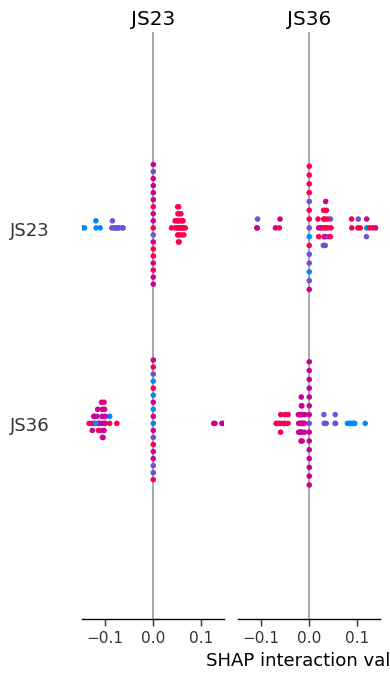

In [21]:
import shap

svc_best.fit(X_train, y_train)

# KernelExplainer를 사용하여 소프트 투표 분류기를 설명
explainer = shap.KernelExplainer(svc_best.predict_proba, X_train)
shap_values = explainer.shap_values(X_test)

# SHAP 값을 시각화
shap.summary_plot(shap_values, X_test)

In [29]:
imp_v = svc_best.feature_importances_
imp_v = pd.Series(imp_v, index= X.columns)
imp_v.sort_values(ascending=False).head(15)

AttributeError: 'SVC' object has no attribute 'feature_importances_'

In [22]:
shap.plots.waterfall(shap_values[0])

TypeError: The waterfall plot requires an `Explanation` object as the `shap_values` argument.

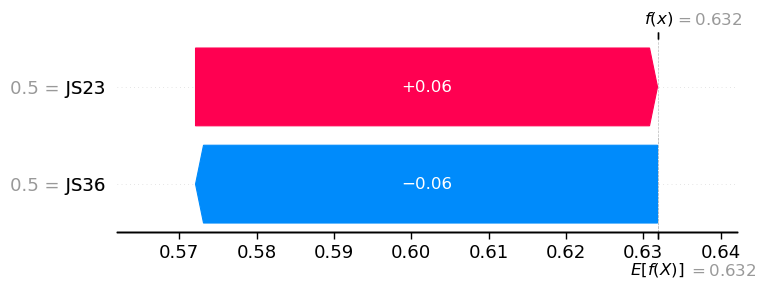

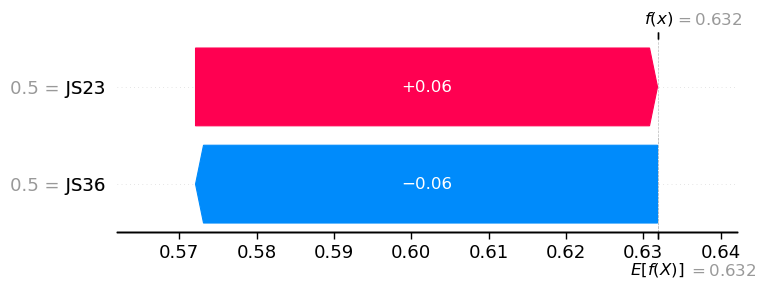

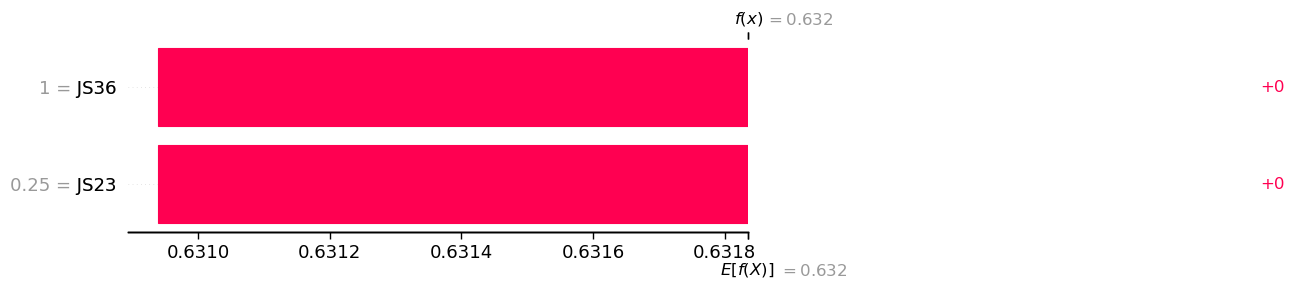

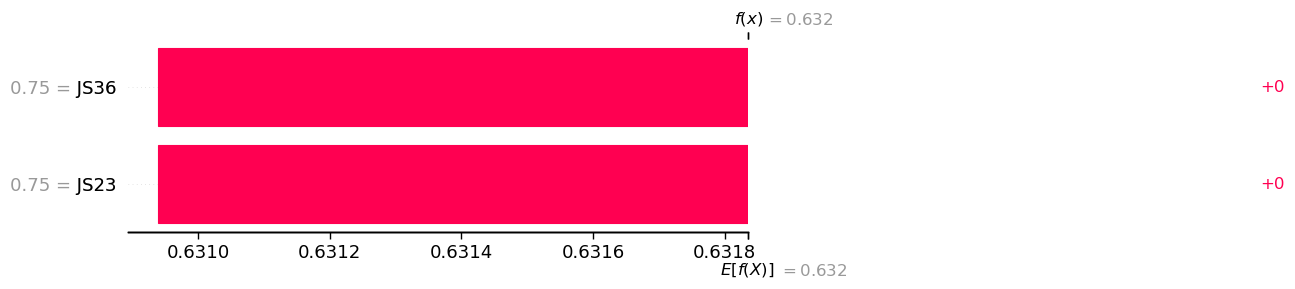

In [23]:
# Waterfall plot을 위해 Explanation 객체 생성
# 첫 번째 샘플에 대해 (이진 분류의 경우 클래스 1 사용)
explanation = shap.Explanation(
    values=shap_values[1][0],  # [클래스][샘플]
    base_values=explainer.expected_value[1],
    data=X_test.iloc[0].values,
    feature_names=X_test.columns.tolist()
)

# Waterfall plot 생성
shap.plots.waterfall(explanation)

# 또는 여러 샘플 확인하고 싶다면:
for i in range(min(3, len(X_test))):  # 처음 3개 샘플
    explanation = shap.Explanation(
        values=shap_values[1][i],
        base_values=explainer.expected_value[1],
        data=X_test.iloc[i].values,
        feature_names=X_test.columns.tolist()
    )
    shap.plots.waterfall(explanation)

In [30]:
# SHAP, permutation importance 사용
from sklearn.inspection import permutation_importance

# 1. Permutation Importance
perm_importance = permutation_importance(
    svc_best, X_test, y_test, n_repeats=10, random_state=42
)

feature_imp_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance': perm_importance.importances_mean,
    'std': perm_importance.importances_std
}).sort_values('importance', ascending=False)

print(feature_imp_df.head(10))


   feature  importance       std
1     JS23    0.059677  0.014516
6     JS17    0.024194  0.014870
5     JS21    0.022581  0.014783
10     JP4    0.017742  0.008686
2     JS35    0.017742  0.013398
31     JP6    0.017742  0.008686
38     JP5    0.016129  0.007213
13     JS6    0.014516  0.008686
0     JS36    0.012903  0.014061
9     JS26    0.011290  0.007391


In [31]:
# 2. SHAP 기반 중요도 (이미 계산한 shap_values 활용)
shap_importance = np.abs(shap_values[1]).mean(axis=0)

shap_imp_df = pd.DataFrame({
    'feature': X_test.columns,
    'shap_importance': shap_importance
}).sort_values('shap_importance', ascending=False)

print(shap_imp_df.head(10))

ValueError: All arrays must be of the same length

In [24]:
# 1. 특정 샘플의 모든 SHAP 값 확인
sample_idx = 0
shap_df = pd.DataFrame({
    'feature': X_test.columns,
    'feature_value': X_test.iloc[sample_idx].values,
    'shap_value': shap_values[1][sample_idx],
    'abs_shap': np.abs(shap_values[1][sample_idx])
}).sort_values('abs_shap', ascending=False)

print(f"\n샘플 {sample_idx}의 모든 변수 SHAP 값:")
print(shap_df)

# 0이 아닌 SHAP 값만 확인
print(f"\n0이 아닌 SHAP 값을 가진 변수:")
print(shap_df[shap_df['abs_shap'] > 0.001])



ValueError: All arrays must be of the same length

In [ ]:
# 먼저 shap_values의 구조 확인 - SHAP values의 길이가 62개인데 X_test의 피처는 39개= X_train의 샘플을 너무 많이 사용
print("SHAP values 구조 확인:")
print(f"Type: {type(shap_values)}")
print(f"Length: {len(shap_values)}")
if isinstance(shap_values, list):
    print(f"Class 0 shape: {shap_values[0].shape}")
    print(f"Class 1 shape: {shap_values[1].shape}")
print(f"X_test shape: {X_test.shape}")
print(f"Number of features: {len(X_test.columns)}")

SHAP values 구조 확인:
Type: <class 'numpy.ndarray'>
Length: 62
X_test shape: (62, 39)
Number of features: 39


In [26]:
# 1. KernelExplainer 재생성 (background 샘플 수 제한)
# X_train에서 대표 샘플만 사용 (예: 100개 또는 kmeans로 요약)
background_data = shap.sample(X_train, 100)  # 또는 shap.kmeans(X_train, 10)

explainer = shap.KernelExplainer(svc_best.predict_proba, background_data)
shap_values = explainer.shap_values(X_test)

# 이제 shap_values[1]의 shape은 (n_samples, 39)가 됩니다
print(f"새로운 SHAP values shape: {shap_values[1].shape}")

  0%|          | 0/62 [00:00<?, ?it/s]

새로운 SHAP values shape: (39, 2)


In [27]:
# 2. 개별 샘플 분석
sample_idx = 0
shap_df = pd.DataFrame({
    'feature': X_test.columns.tolist(),
    'feature_value': X_test.iloc[sample_idx].values,
    'shap_value': shap_values[1][sample_idx],
    'abs_shap': np.abs(shap_values[1][sample_idx])
}).sort_values('abs_shap', ascending=False)

print(f"\n샘플 {sample_idx}의 모든 변수 SHAP 값:")
print(shap_df)

# 0이 아닌 SHAP 값
print(f"\n기여도가 있는 변수들:")
print(shap_df[shap_df['abs_shap'] > 0.001])

ValueError: All arrays must be of the same length

In [28]:
# 현재 상황에서 임시 해결책
# shap_values의 길이가 왜 62인지 확인
print(f"explainer.expected_value: {explainer.expected_value}")
print(f"shap_values 구조 확인:")
for i, sv in enumerate(shap_values):
    print(f"  Class {i} shape: {sv.shape}")

# X_train 샘플 수 확인
print(f"X_train shape: {X_train.shape}")

# 올바른 shape이 될 때까지 explainer 재생성 필요

explainer.expected_value: [0.364317 0.635683]
shap_values 구조 확인:
  Class 0 shape: (39, 2)
  Class 1 shape: (39, 2)
  Class 2 shape: (39, 2)
  Class 3 shape: (39, 2)
  Class 4 shape: (39, 2)
  Class 5 shape: (39, 2)
  Class 6 shape: (39, 2)
  Class 7 shape: (39, 2)
  Class 8 shape: (39, 2)
  Class 9 shape: (39, 2)
  Class 10 shape: (39, 2)
  Class 11 shape: (39, 2)
  Class 12 shape: (39, 2)
  Class 13 shape: (39, 2)
  Class 14 shape: (39, 2)
  Class 15 shape: (39, 2)
  Class 16 shape: (39, 2)
  Class 17 shape: (39, 2)
  Class 18 shape: (39, 2)
  Class 19 shape: (39, 2)
  Class 20 shape: (39, 2)
  Class 21 shape: (39, 2)
  Class 22 shape: (39, 2)
  Class 23 shape: (39, 2)
  Class 24 shape: (39, 2)
  Class 25 shape: (39, 2)
  Class 26 shape: (39, 2)
  Class 27 shape: (39, 2)
  Class 28 shape: (39, 2)
  Class 29 shape: (39, 2)
  Class 30 shape: (39, 2)
  Class 31 shape: (39, 2)
  Class 32 shape: (39, 2)
  Class 33 shape: (39, 2)
  Class 34 shape: (39, 2)
  Class 35 shape: (39, 2)
  Class 3

In [32]:
# 2. 다른 샘플들도 확인 (다양한 변수가 나타날 수 있음)
for i in range(min(5, len(X_test))):
    shap_df = pd.DataFrame({
        'feature': X_test.columns,
        'shap_value': shap_values[1][i],
        'abs_shap': np.abs(shap_values[1][i])
    }).sort_values('abs_shap', ascending=False)
    
    non_zero = shap_df[shap_df['abs_shap'] > 0.001]
    print(f"\n샘플 {i}: {len(non_zero)}개 변수가 기여")
    print(non_zero.head(10))



ValueError: All arrays must be of the same length

In [33]:
# 3. 전체적인 변수 중요도 (모든 샘플에 걸쳐)
import matplotlib.pyplot as plt
shap.summary_plot(shap_values[1], X_test, plot_type="bar", max_display=20)

AssertionError: The shape of the shap_values matrix does not match the shape of the provided data matrix.

In [34]:
def analyze_individual_prediction(sample_idx, shap_values, X_test, feature_names, 
                                 stress_inducing, stress_mitigating, neutral_factors):
    """
    개별 샘플에 대한 SHAP 값을 유발/완화/중립 요인으로 분류하여 분석
    """
    # 해당 샘플의 SHAP 값
    sample_shap = shap_values[1][sample_idx]
    sample_data = X_test.iloc[sample_idx]
    
    # 데이터프레임 생성
    contribution_df = pd.DataFrame({
        'feature': feature_names,
        'shap_value': sample_shap,
        'feature_value': sample_data.values,
        'abs_contribution': np.abs(sample_shap)
    })
    
    # 요인별 분류
    contribution_df['factor_type'] = contribution_df['feature'].apply(
        lambda x: 'Stress-Inducing' if x in stress_inducing 
        else ('Stress-Mitigating' if x in stress_mitigating else 'Neutral')
    )
    
    # SHAP 값의 방향 (양수: 스트레스 증가, 음수: 스트레스 감소)
    contribution_df['impact'] = contribution_df['shap_value'].apply(
        lambda x: 'Increasing Stress' if x > 0 else 'Decreasing Stress'
    )
    
    # 정렬
    contribution_df = contribution_df.sort_values('abs_contribution', ascending=False)
    
    return contribution_df

In [37]:
def plot_individual_contribution(contribution_df, sample_idx, base_value, prediction):
    """
    개별 샘플의 기여도를 시각화
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
    
    # 왼쪽: 전체 기여도 (SHAP 방향)
    colors_shap = ['#FF6B6B' if x > 0 else '#4ECDC4' 
                   for x in contribution_df['shap_value']]
    
    ax1.barh(range(len(contribution_df)), contribution_df['shap_value'], 
             color=colors_shap, alpha=0.7)
    ax1.set_yticks(range(len(contribution_df)))
    ax1.set_yticklabels(contribution_df['feature'])
    ax1.set_xlabel('SHAP Value (Contribution to Prediction)', fontsize=12)
    ax1.set_title(f'Sample {sample_idx}: Feature Contributions\n' + 
                  f'Base Value: {base_value:.3f} → Prediction: {prediction:.3f}',
                  fontsize=14, fontweight='bold')
    ax1.axvline(x=0, color='black', linestyle='--', linewidth=1)
    ax1.grid(axis='x', alpha=0.3)

    # 범례 추가
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#FF6B6B', alpha=0.7, label='Increasing Stress (Positive SHAP)'),
        Patch(facecolor='#4ECDC4', alpha=0.7, label='Decreasing Stress (Negative SHAP)')
    ]
    ax1.legend(handles=legend_elements, loc='best')
    
    # 오른쪽: 요인 유형별 분류
    color_map = {
        'Stress-Inducing': '#FF6B6B',
        'Stress-Mitigating': '#4ECDC4',
        'Neutral': '#FFD93D'
    }
    colors_type = [color_map[x] for x in contribution_df['factor_type']]
    
    ax2.barh(range(len(contribution_df)), contribution_df['abs_contribution'], 
             color=colors_type, alpha=0.7)
    ax2.set_yticks(range(len(contribution_df)))
    ax2.set_yticklabels(contribution_df['feature'])
    ax2.set_xlabel('Absolute Contribution (|SHAP Value|)', fontsize=12)
    ax2.set_title(f'Sample {sample_idx}: Contributions by Factor Type\n' + 
                  f'(Sorted by Importance)',
                  fontsize=14, fontweight='bold')
    ax2.grid(axis='x', alpha=0.3)
    
    # 범례
    legend_elements2 = [
        Patch(facecolor='#FF6B6B', alpha=0.7, label='Stress-Inducing Factors'),
        Patch(facecolor='#4ECDC4', alpha=0.7, label='Stress-Mitigating Factors'),
        Patch(facecolor='#FFD93D', alpha=0.7, label='Neutral Factors')
    ]
    ax2.legend(handles=legend_elements2, loc='best')
    
    plt.tight_layout()
    plt.show()

In [38]:
def summarize_individual_factors(contribution_df):
    """
    개별 샘플의 요인 요약
    """
    print("\n" + "="*80)
    print("INDIVIDUAL PREDICTION ANALYSIS")
    print("="*80)
    
    # 요인 유형별 요약
    print("\n📊 Summary by Factor Type:")
    print("-" * 80)
    type_summary = contribution_df.groupby('factor_type').agg({
        'shap_value': ['sum', 'mean', 'count'],
        'abs_contribution': 'sum'
    }).round(4)
    print(type_summary)
    
    # SHAP 방향별 요약
    print("\n📊 Summary by Impact Direction:")
    print("-" * 80)
    impact_summary = contribution_df.groupby('impact').agg({
        'shap_value': ['sum', 'mean', 'count'],
        'abs_contribution': 'sum'
    }).round(4)
    print(impact_summary)
    
    # Top 5 요인
    print("\n🔝 Top 5 Contributing Factors:")
    print("-" * 80)
    top5 = contribution_df.head(5)[['feature', 'feature_value', 'shap_value', 
                                     'factor_type', 'impact']]
    print(top5.to_string(index=False))
    
    # 유발 vs 완화 요인 분석
    print("\n⚖️  Stress-Inducing vs Stress-Mitigating Analysis:")
    print("-" * 80)
    
    inducing = contribution_df[contribution_df['factor_type'] == 'Stress-Inducing']
    mitigating = contribution_df[contribution_df['factor_type'] == 'Stress-Mitigating']
    
    print(f"Stress-Inducing Factors:")
    print(f"  - Total contribution: {inducing['shap_value'].sum():.4f}")
    print(f"  - Average contribution: {inducing['shap_value'].mean():.4f}")
    print(f"  - Count: {len(inducing)}")
    
    print(f"\nStress-Mitigating Factors:")
    print(f"  - Total contribution: {mitigating['shap_value'].sum():.4f}")
    print(f"  - Average contribution: {mitigating['shap_value'].mean():.4f}")
    print(f"  - Count: {len(mitigating)}")


In [39]:
# 요인 분류 정의 (이미지에서 본 분류 사용)
stress_inducing = ['JP6', 'JP4', 'JP5', 'JS3', 'JS11', 'JS10', 'JS18', 'JS16', 'JS13', 'JS19', 'JS23', 'JS21', 'JS26', 'JS20', 'JS28', 'JS24', 'JS35', 'JS36', 'JS5', 'JS29', 'JS2']
stress_mitigating = ['JS4', 'JS8', 'JS6', 'JS7', 'JS17', 'JS12', 'JS14', 
                     'JS25', 'JS31', 'JS30', 'JS33', 'JS32', 'JS15', 'JS22', 'JS1']
neutral_factors = ['Sperm quaily', 'Household income', 'Education level']

# 특정 샘플 분석 (예: 첫 번째 테스트 샘플)
sample_idx = 0
contribution_df = analyze_individual_prediction(
    sample_idx=sample_idx,
    shap_values=shap_values,
    X_test=X_test,
    feature_names=X_test.columns.tolist(),
    stress_inducing=stress_inducing,
    stress_mitigating=stress_mitigating,
    neutral_factors=neutral_factors
)

# 시각화
plot_individual_contribution(
    contribution_df=contribution_df,
    sample_idx=sample_idx,
    base_value=explainer.expected_value[1],
    prediction=svc_best.predict_proba(X_test.iloc[[sample_idx]])[0][1]
)

# 요약 출력
summarize_individual_factors(contribution_df)


ValueError: All arrays must be of the same length

In [40]:
# Background 데이터를 적절한 크기로 샘플링
background_data = shap.sample(X_train, 100)  # 100개 샘플만 사용
print(f"Background data shape: {background_data.shape}")

Background data shape: (100, 39)


In [41]:
# Explainer 재생성
explainer = shap.KernelExplainer(svc_best.predict_proba, background_data)

In [42]:
# SHAP values 재계산 (시간이 좀 걸립니다)
print("SHAP values 계산 중... (시간이 걸릴 수 있습니다)")
shap_values = explainer.shap_values(X_test[:50])  # 처음 50개만 계산

SHAP values 계산 중... (시간이 걸릴 수 있습니다)


  0%|          | 0/50 [00:00<?, ?it/s]

In [43]:
print("\n=== Shape 확인 ===")
print(f"shap_values[1] shape: {shap_values[1].shape}")
print(f"X_test shape: {X_test[:50].shape}")
print(f"Feature 개수: {len(X_test.columns)}")


=== Shape 확인 ===
shap_values[1] shape: (39, 2)
X_test shape: (50, 39)
Feature 개수: 39


In [44]:
sample_idx = 0

shap_df = pd.DataFrame({
    'feature': X_test.columns.tolist(),
    'feature_value': X_test.iloc[sample_idx].values,
    'shap_value': shap_values[1][sample_idx],
    'abs_shap': np.abs(shap_values[1][sample_idx])
}).sort_values('abs_shap', ascending=False)

ValueError: All arrays must be of the same length

In [45]:
# ============================================
# 디버깅: 각 배열 길이 확인
# ============================================
sample_idx = 0

print("=== 길이 확인 ===")
print(f"X_test.columns 길이: {len(X_test.columns.tolist())}")
print(f"X_test.iloc[{sample_idx}].values 길이: {len(X_test.iloc[sample_idx].values)}")
print(f"shap_values[1][{sample_idx}] 길이: {len(shap_values[1][sample_idx])}")

=== 길이 확인 ===
X_test.columns 길이: 39
X_test.iloc[0].values 길이: 39
shap_values[1][0] 길이: 2


In [46]:
print("\n=== 실제 값들 ===")
print(f"X_test.columns: {X_test.columns.tolist()}")
print(f"X_test.iloc[{sample_idx}].values: {X_test.iloc[sample_idx].values}")
print(f"shap_values[1][{sample_idx}]: {shap_values[1][sample_idx]}")


=== 실제 값들 ===
X_test.columns: ['JS36', 'JS23', 'JS35', 'Household income', 'JS33', 'JS21', 'JS17', 'JS11', 'JS24', 'JS26', 'JP4', 'Sperm quality', 'JS5', 'JS6', 'JS15', 'JS4', 'JS7', 'Educational level', 'JS20', 'JS14', 'JS22', 'JS29', 'JS10', 'JS12', 'JS2', 'JS28', 'JS18', 'JS25', 'JS8', 'JS31', 'JS30', 'JP6', 'JS3', 'JS32', 'JS16', 'JS13', 'JS19', 'JS1', 'JP5']
X_test.iloc[0].values: [0.5        0.5        0.5        0.11111111 0.5        0.5
 0.5        0.5        0.5        0.5        0.33333333 0.
 0.5        0.75       0.5        0.5        0.5        0.57142857
 0.5        0.5        0.5        0.75       0.5        0.5
 0.25       0.5        0.5        0.5        0.5        0.33333333
 0.33333333 0.5        0.5        0.33333333 0.5        0.5
 0.25       0.5        0.5       ]
shap_values[1][0]: [-0.06129005  0.06129005]


In [47]:
# ============================================
# 해결책 1: Explainer 완전히 새로 생성
# ============================================
import shap

# 1. Background 데이터 준비
background_data = shap.sample(X_train, 50)  # 50개 샘플
print(f"Background data shape: {background_data.shape}")

Background data shape: (50, 39)


In [48]:
# 2. Explainer 생성
explainer = shap.KernelExplainer(
    model=svc_best.predict_proba,
    data=background_data
)

# 3. SHAP values 계산 (테스트 샘플 10개만)
print("SHAP values 계산 중...")
shap_values_new = explainer.shap_values(X_test.iloc[:10])

SHAP values 계산 중...


  0%|          | 0/10 [00:00<?, ?it/s]

In [49]:
# 4. 구조 확인
print("\n=== 새로운 SHAP 구조 ===")
print(f"Type: {type(shap_values_new)}")
if isinstance(shap_values_new, list):
    for i, sv in enumerate(shap_values_new):
        print(f"Class {i} shape: {sv.shape}")
else:
    print(f"Shape: {shap_values_new.shape}")


=== 새로운 SHAP 구조 ===
Type: <class 'numpy.ndarray'>
Shape: (10, 39, 2)


In [50]:
# 5. DataFrame 생성
sample_idx = 0

# 이진 분류의 경우 클래스 1 사용
if isinstance(shap_values_new, list):
    sample_shap = shap_values_new[1][sample_idx]
else:
    sample_shap = shap_values_new[sample_idx]

print(f"\nSample SHAP length: {len(sample_shap)}")
print(f"Expected length: {len(X_test.columns)}")


Sample SHAP length: 39
Expected length: 39


In [51]:
if len(sample_shap) == len(X_test.columns):
    shap_df = pd.DataFrame({
        'feature': X_test.columns.tolist(),
        'feature_value': X_test.iloc[sample_idx].values,
        'shap_value': sample_shap,
        'abs_shap': np.abs(sample_shap)
    }).sort_values('abs_shap', ascending=False)
    
    print("\n✅ DataFrame 생성 성공!")
    print(shap_df)
    
    print("\n=== 기여도 있는 변수 ===")
    print(shap_df[shap_df['abs_shap'] > 0.001])
else:
    print("❌ 여전히 길이가 맞지 않습니다!")
    print("다른 Explainer를 시도해보세요.")

ValueError: Per-column arrays must each be 1-dimensional

In [52]:
# ============================================
# 배열 차원 확인
# ============================================
sample_idx = 0

print("=== 배열 차원 확인 ===")
print(f"X_test.iloc[{sample_idx}].values shape: {X_test.iloc[sample_idx].values.shape}")
print(f"sample_shap shape: {sample_shap.shape}")

=== 배열 차원 확인 ===
X_test.iloc[0].values shape: (39,)
sample_shap shape: (39, 2)


In [54]:
# ============================================
# 해결책: flatten() 사용
# ============================================
shap_df = pd.DataFrame({
    'feature': X_test.columns.tolist(),
    'feature_value': X_test.iloc[sample_idx].values.flatten(),  # flatten 추가
    'shap_value': sample_shap.flatten(),  # flatten 추가
    'abs_shap': np.abs(sample_shap).flatten()  # flatten 추가
}).sort_values('abs_shap', ascending=False)

print("\n✅ DataFrame 생성:")
print(shap_df)


ValueError: All arrays must be of the same length

In [55]:
# ============================================
# 상세 디버깅
# ============================================
sample_idx = 0

print("=== 상세 배열 정보 ===")
print(f"\n1. X_test.columns:")
print(f"   Type: {type(X_test.columns)}")
print(f"   Length: {len(X_test.columns)}")
print(f"   First 5: {X_test.columns[:5].tolist()}")

print(f"\n2. X_test.iloc[{sample_idx}].values:")
print(f"   Type: {type(X_test.iloc[sample_idx].values)}")
print(f"   Shape: {X_test.iloc[sample_idx].values.shape}")
print(f"   Length: {len(X_test.iloc[sample_idx].values)}")
print(f"   First 5: {X_test.iloc[sample_idx].values[:5]}")

print(f"\n3. sample_shap:")
print(f"   Type: {type(sample_shap)}")
print(f"   Shape: {sample_shap.shape if hasattr(sample_shap, 'shape') else 'N/A'}")
print(f"   Length: {len(sample_shap)}")
print(f"   Content: {sample_shap}")
print(f"   First 5: {sample_shap[:5] if len(sample_shap) > 5 else sample_shap}")

=== 상세 배열 정보 ===

1. X_test.columns:
   Type: <class 'pandas.core.indexes.base.Index'>
   Length: 39
   First 5: ['JS36', 'JS23', 'JS35', 'Household income', 'JS33']

2. X_test.iloc[0].values:
   Type: <class 'numpy.ndarray'>
   Shape: (39,)
   Length: 39
   First 5: [0.5        0.5        0.5        0.11111111 0.5       ]

3. sample_shap:
   Type: <class 'numpy.ndarray'>
   Shape: (39, 2)
   Length: 39
   Content: [[ 0.04156209 -0.04156209]
 [ 0.          0.        ]
 [ 0.05726793 -0.05726793]
 [ 0.          0.        ]
 [ 0.          0.        ]
 [ 0.          0.        ]
 [ 0.04271739 -0.04271739]
 [ 0.          0.        ]
 [ 0.          0.        ]
 [ 0.          0.        ]
 [ 0.05034262 -0.05034262]
 [ 0.          0.        ]
 [ 0.          0.        ]
 [ 0.          0.        ]
 [ 0.          0.        ]
 [ 0.04302494 -0.04302494]
 [ 0.          0.        ]
 [ 0.          0.        ]
 [ 0.          0.        ]
 [ 0.          0.        ]
 [ 0.          0.        ]
 [ 0.         

In [56]:
# ============================================
# 문제: sample_shap이 2개만 있는 경우
# ============================================
if len(sample_shap) != len(X_test.columns):
    print(f"\n❌ 길이 불일치!")
    print(f"   Expected: {len(X_test.columns)}")
    print(f"   Got: {len(sample_shap)}")
    print("\n해결책: SHAP Explainer를 처음부터 다시 생성해야 합니다.")

In [61]:
    print("\n=== SHAP 재계산 시작 ===")
    
    # 1. Background 데이터
    background = shap.sample(X_train, 50)
    print(f"Background shape: {background.shape}")


=== SHAP 재계산 시작 ===
Background shape: (50, 39)


In [62]:
    # 2. Explainer 생성
    explainer_new = shap.KernelExplainer(
        model=svc_best.predict_proba,
        data=background
    )
    
    # 3. 한 개 샘플만 계산 (테스트)
    print("한 개 샘플 SHAP 계산 중...")
    single_sample = X_test.iloc[[0]]  # 2D로 유지
    shap_values_new = explainer_new.shap_values(single_sample)

한 개 샘플 SHAP 계산 중...


  0%|          | 0/1 [00:00<?, ?it/s]

In [63]:
    print(f"\n=== 새 SHAP 구조 ===")
    print(f"Type: {type(shap_values_new)}")
    if isinstance(shap_values_new, list):
        print(f"List length: {len(shap_values_new)}")
        for i, sv in enumerate(shap_values_new):
            print(f"  Class {i} shape: {sv.shape}")
            print(f"  Class {i} first row: {sv[0][:5]}...")


=== 새 SHAP 구조 ===
Type: <class 'numpy.ndarray'>


In [64]:
    # 4. 올바른 SHAP 값 추출
    if isinstance(shap_values_new, list):
        correct_shap = shap_values_new[1][0]  # 클래스 1, 첫 번째 샘플
    else:
        correct_shap = shap_values_new[0]
    
    print(f"\nCorrect SHAP length: {len(correct_shap)}")
    print(f"X_test columns length: {len(X_test.columns)}")


Correct SHAP length: 39
X_test columns length: 39


In [65]:
    # 5. DataFrame 생성
    if len(correct_shap) == len(X_test.columns):
        shap_df = pd.DataFrame({
            'feature': X_test.columns.tolist(),
            'feature_value': X_test.iloc[0].values,
            'shap_value': correct_shap,
            'abs_shap': np.abs(correct_shap)
        }).sort_values('abs_shap', ascending=False)
        
        print("\n✅✅✅ 성공! ✅✅✅")
        print(shap_df)
        
        print("\n=== 기여도 Top 10 ===")
        print(shap_df.head(10))
    else:
        print("\n❌ 여전히 실패")
        print("SVC 모델 구조를 확인해주세요:")
        print(f"svc_best type: {type(svc_best)}")
        print(f"svc_best: {svc_best}")

ValueError: Per-column arrays must each be 1-dimensional

In [66]:
# ============================================
# 올바른 SHAP 값 추출
# ============================================
sample_idx = 0

# sample_shap이 (39, 2) 형태이므로 클래스 1만 선택
if len(sample_shap.shape) == 2:
    # 2차원인 경우: 클래스 1 (두 번째 열) 선택
    shap_values_for_class1 = sample_shap[:, 1]
else:
    # 1차원인 경우: 그대로 사용
    shap_values_for_class1 = sample_shap

print(f"SHAP values for class 1 shape: {shap_values_for_class1.shape}")
print(f"Length: {len(shap_values_for_class1)}")

SHAP values for class 1 shape: (39,)
Length: 39


In [67]:
# ============================================
# DataFrame 생성
# ============================================
shap_df = pd.DataFrame({
    'feature': X_test.columns.tolist(),
    'feature_value': X_test.iloc[sample_idx].values,
    'shap_value': shap_values_for_class1,
    'abs_shap': np.abs(shap_values_for_class1)
}).sort_values('abs_shap', ascending=False)

print("\n✅✅✅ 성공! ✅✅✅")
print(shap_df)

print("\n=== 기여도 Top 15 ===")
print(shap_df.head(15))

print("\n=== 기여도 있는 변수 (abs_shap > 0.001) ===")
significant = shap_df[shap_df['abs_shap'] > 0.001]
print(significant)
print(f"\n총 {len(significant)}개 변수가 예측에 기여")


✅✅✅ 성공! ✅✅✅
              feature  feature_value  shap_value  abs_shap
2                JS35       0.500000   -0.057268  0.057268
10                JP4       0.333333   -0.050343  0.050343
27               JS25       0.500000   -0.046574  0.046574
30               JS30       0.333333   -0.044645  0.044645
29               JS31       0.333333   -0.043244  0.043244
15                JS4       0.500000   -0.043025  0.043025
6                JS17       0.500000   -0.042717  0.042717
0                JS36       0.500000   -0.041562  0.041562
38                JP5       0.500000   -0.036538  0.036538
31                JP6       0.500000   -0.032787  0.032787
9                JS26       0.500000    0.000000  0.000000
8                JS24       0.500000    0.000000  0.000000
37                JS1       0.500000    0.000000  0.000000
36               JS19       0.250000    0.000000  0.000000
35               JS13       0.500000    0.000000  0.000000
34               JS16       0.500000    0.0

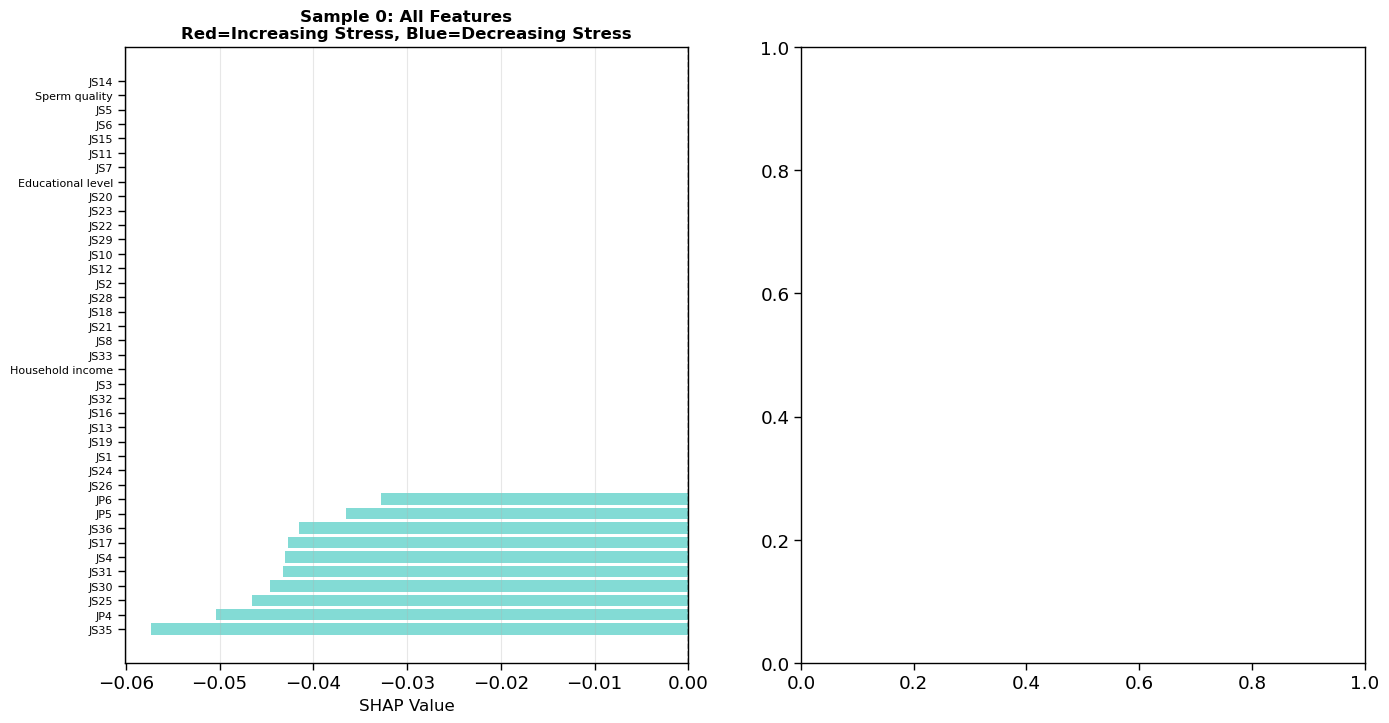

In [68]:
# ============================================
# 시각화
# ============================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# 왼쪽: SHAP 값 전체 (양수/음수)
colors = ['#FF6B6B' if x > 0 else '#4ECDC4' for x in shap_df['shap_value']]
ax1.barh(range(len(shap_df)), shap_df['shap_value'], color=colors, alpha=0.7)
ax1.set_yticks(range(len(shap_df)))
ax1.set_yticklabels(shap_df['feature'], fontsize=8)
ax1.set_xlabel('SHAP Value', fontsize=12)
ax1.set_title(f'Sample {sample_idx}: All Features\nRed=Increasing Stress, Blue=Decreasing Stress', 
              fontsize=12, fontweight='bold')
ax1.axvline(x=0, color='black', linestyle='--', linewidth=1)
ax1.grid(axis='x', alpha=0.3)

In [69]:
# 오른쪽: 절대값 Top 20
top20 = shap_df.head(20)
colors_top = ['#FF6B6B' if x > 0 else '#4ECDC4' for x in top20['shap_value']]
ax2.barh(range(len(top20)), top20['abs_shap'], color=colors_top, alpha=0.7)
ax2.set_yticks(range(len(top20)))
ax2.set_yticklabels(top20['feature'], fontsize=10)
ax2.set_xlabel('Absolute SHAP Value (Importance)', fontsize=12)
ax2.set_title(f'Sample {sample_idx}: Top 20 Most Important Features', 
              fontsize=12, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

<Figure size 600x400 with 0 Axes>

In [70]:
# ============================================
# 통계 요약
# ============================================
print("\n" + "="*60)
print("통계 요약")
print("="*60)
print(f"총 피처 수: {len(shap_df)}")
print(f"양수 SHAP (스트레스 증가 방향): {(shap_df['shap_value'] > 0).sum()}개")
print(f"음수 SHAP (스트레스 감소 방향): {(shap_df['shap_value'] < 0).sum()}개")
print(f"0에 가까운 값 (|SHAP| < 0.001): {(shap_df['abs_shap'] < 0.001).sum()}개")
print(f"유의미한 기여 (|SHAP| > 0.01): {(shap_df['abs_shap'] > 0.01).sum()}개")
print(f"\nSHAP 값 합계: {shap_df['shap_value'].sum():.6f}")
print(f"절대값 합계: {shap_df['abs_shap'].sum():.6f}")


통계 요약
총 피처 수: 39
양수 SHAP (스트레스 증가 방향): 0개
음수 SHAP (스트레스 감소 방향): 10개
0에 가까운 값 (|SHAP| < 0.001): 29개
유의미한 기여 (|SHAP| > 0.01): 10개

SHAP 값 합계: -0.438702
절대값 합계: 0.438702


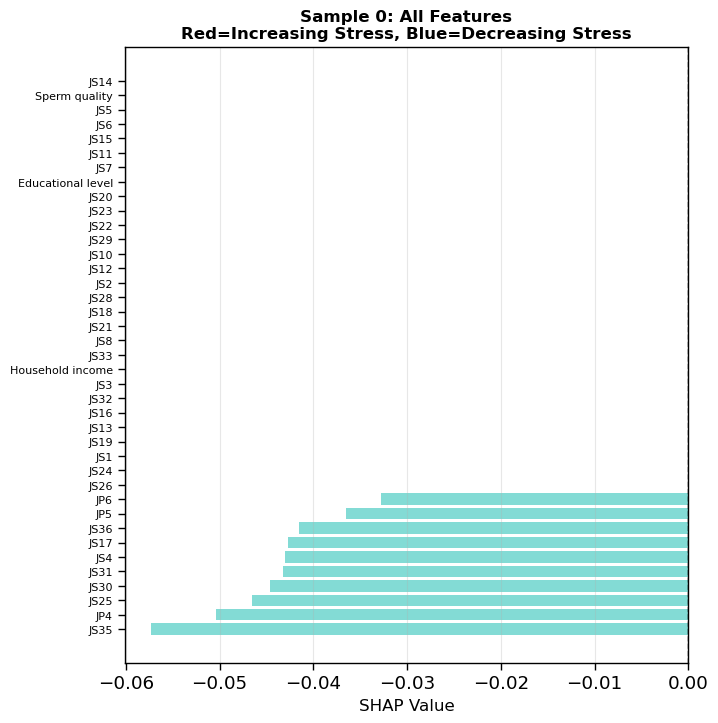

In [71]:
# ============================================
# 시각화 (수정 버전)
# ============================================

# Figure 생성
fig = plt.figure(figsize=(16, 8))

# 서브플롯 1: SHAP 값 전체 (양수/음수)
ax1 = plt.subplot(1, 2, 1)
colors = ['#FF6B6B' if x > 0 else '#4ECDC4' for x in shap_df['shap_value']]
ax1.barh(range(len(shap_df)), shap_df['shap_value'], color=colors, alpha=0.7)
ax1.set_yticks(range(len(shap_df)))
ax1.set_yticklabels(shap_df['feature'], fontsize=8)
ax1.set_xlabel('SHAP Value', fontsize=12)
ax1.set_title(f'Sample {sample_idx}: All Features\nRed=Increasing Stress, Blue=Decreasing Stress', 
              fontsize=12, fontweight='bold')
ax1.axvline(x=0, color='black', linestyle='--', linewidth=1)
ax1.grid(axis='x', alpha=0.3)

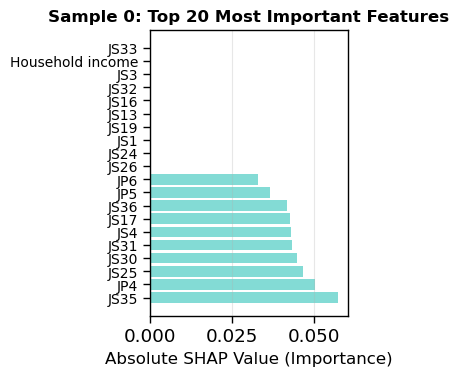

✅ 그래프가 표시되었습니다!


In [ ]:
# 서브플롯 2: 절대값 Top 20
ax2 = plt.subplot(1, 2, 2)
top20 = shap_df.head(20)
colors_top = ['#FF6B6B' if x > 0 else '#4ECDC4' for x in top20['shap_value']]
ax2.barh(range(len(top20)), top20['abs_shap'], color=colors_top, alpha=0.7)
ax2.set_yticks(range(len(top20)))
ax2.set_yticklabels(top20['feature'], fontsize=10)
ax2.set_xlabel('Absolute SHAP Value (Importance)', fontsize=12)
ax2.set_title(f'Sample {sample_idx}: Top 5 Most Important Features', 
              fontsize=12, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ 그래프가 표시되었습니다!")

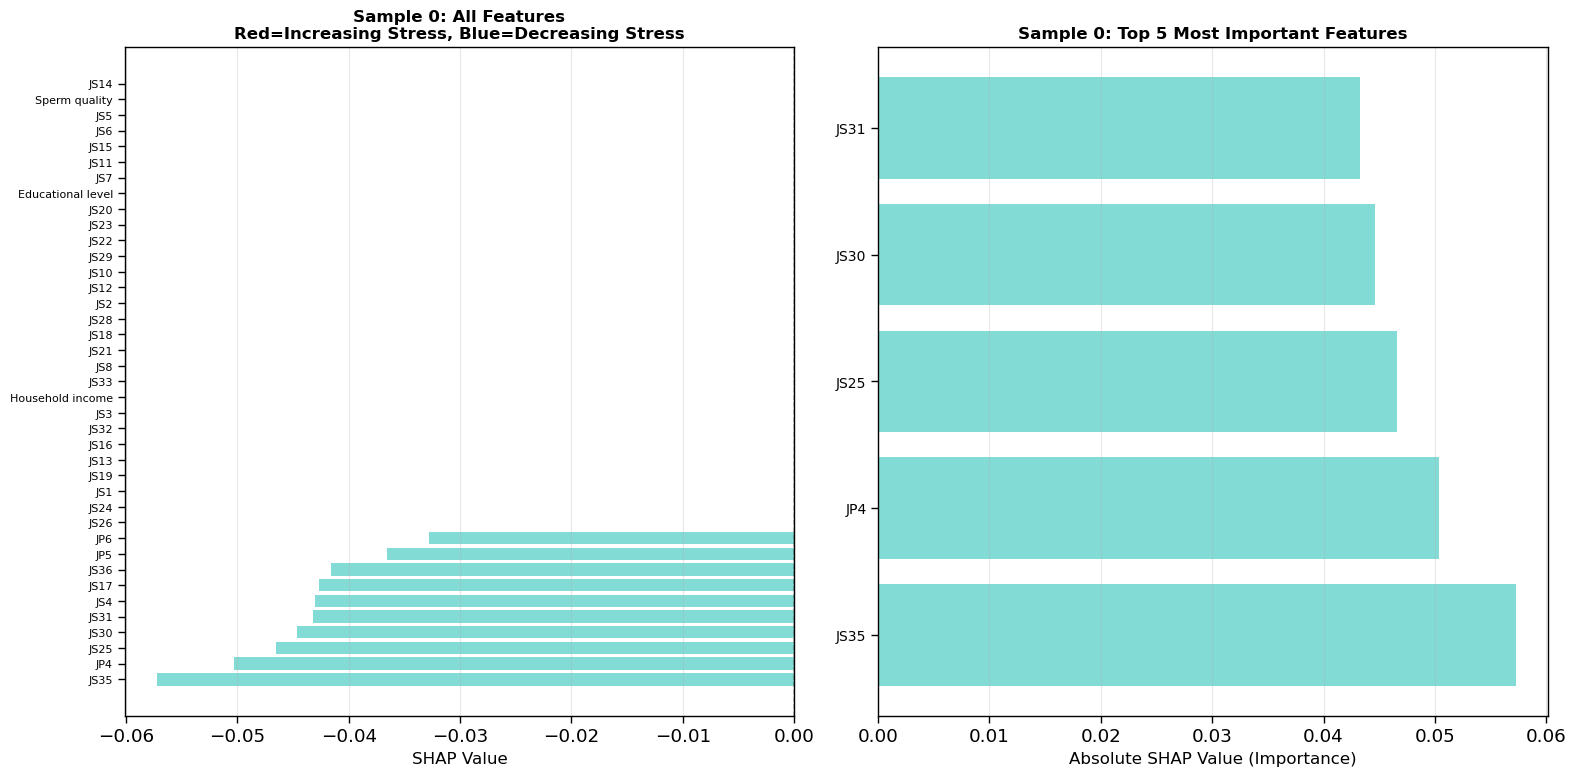

In [74]:
# Figure 생성
fig = plt.figure(figsize=(16, 8))

# 서브플롯 1: SHAP 값 전체 (양수/음수)
ax1 = plt.subplot(1, 2, 1)
colors = ['#FF6B6B' if x > 0 else '#4ECDC4' for x in shap_df['shap_value']]
ax1.barh(range(len(shap_df)), shap_df['shap_value'], color=colors, alpha=0.7)
ax1.set_yticks(range(len(shap_df)))
ax1.set_yticklabels(shap_df['feature'], fontsize=8)
ax1.set_xlabel('SHAP Value', fontsize=12)
ax1.set_title(f'Sample {sample_idx}: All Features\nRed=Increasing Stress, Blue=Decreasing Stress', 
              fontsize=12, fontweight='bold')
ax1.axvline(x=0, color='black', linestyle='--', linewidth=1)
ax1.grid(axis='x', alpha=0.3)

# 서브플롯 2: 절대값 Top 5
ax2 = plt.subplot(1, 2, 2)
top5 = shap_df.head(5)
colors_top = ['#FF6B6B' if x > 0 else '#4ECDC4' for x in top5['shap_value']]
ax2.barh(range(len(top5)), top5['abs_shap'], color=colors_top, alpha=0.7)
ax2.set_yticks(range(len(top5)))
ax2.set_yticklabels(top5['feature'], fontsize=10)
ax2.set_xlabel('Absolute SHAP Value (Importance)', fontsize=12)
ax2.set_title(f'Sample {sample_idx}: Top 5 Most Important Features', 
              fontsize=12, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

In [75]:
sample_idx = 1

# sample_shap이 (39, 2) 형태이므로 클래스 1만 선택
if len(sample_shap.shape) == 2:
    shap_values_for_class1 = sample_shap[:, 1]
else:
    shap_values_for_class1 = sample_shap

# DataFrame 생성
shap_df = pd.DataFrame({
    'feature': X_test.columns.tolist(),
    'feature_value': X_test.iloc[sample_idx].values,  # ← sample_idx 자동 적용
    'shap_value': shap_values_for_class1,
    'abs_shap': np.abs(shap_values_for_class1)
}).sort_values('abs_shap', ascending=False)

print(f"\n✅ 샘플 {sample_idx} 분석 결과:")
print(shap_df.head(15))


✅ 샘플 1 분석 결과:
   feature  feature_value  shap_value  abs_shap
2     JS35       0.750000   -0.057268  0.057268
10     JP4       1.000000   -0.050343  0.050343
27    JS25       0.750000   -0.046574  0.046574
30    JS30       1.000000   -0.044645  0.044645
29    JS31       0.666667   -0.043244  0.043244
15     JS4       0.500000   -0.043025  0.043025
6     JS17       0.750000   -0.042717  0.042717
0     JS36       1.000000   -0.041562  0.041562
38     JP5       1.000000   -0.036538  0.036538
31     JP6       1.000000   -0.032787  0.032787
9     JS26       0.750000    0.000000  0.000000
8     JS24       0.250000    0.000000  0.000000
37     JS1       0.750000    0.000000  0.000000
36    JS19       1.000000    0.000000  0.000000
35    JS13       1.000000    0.000000  0.000000


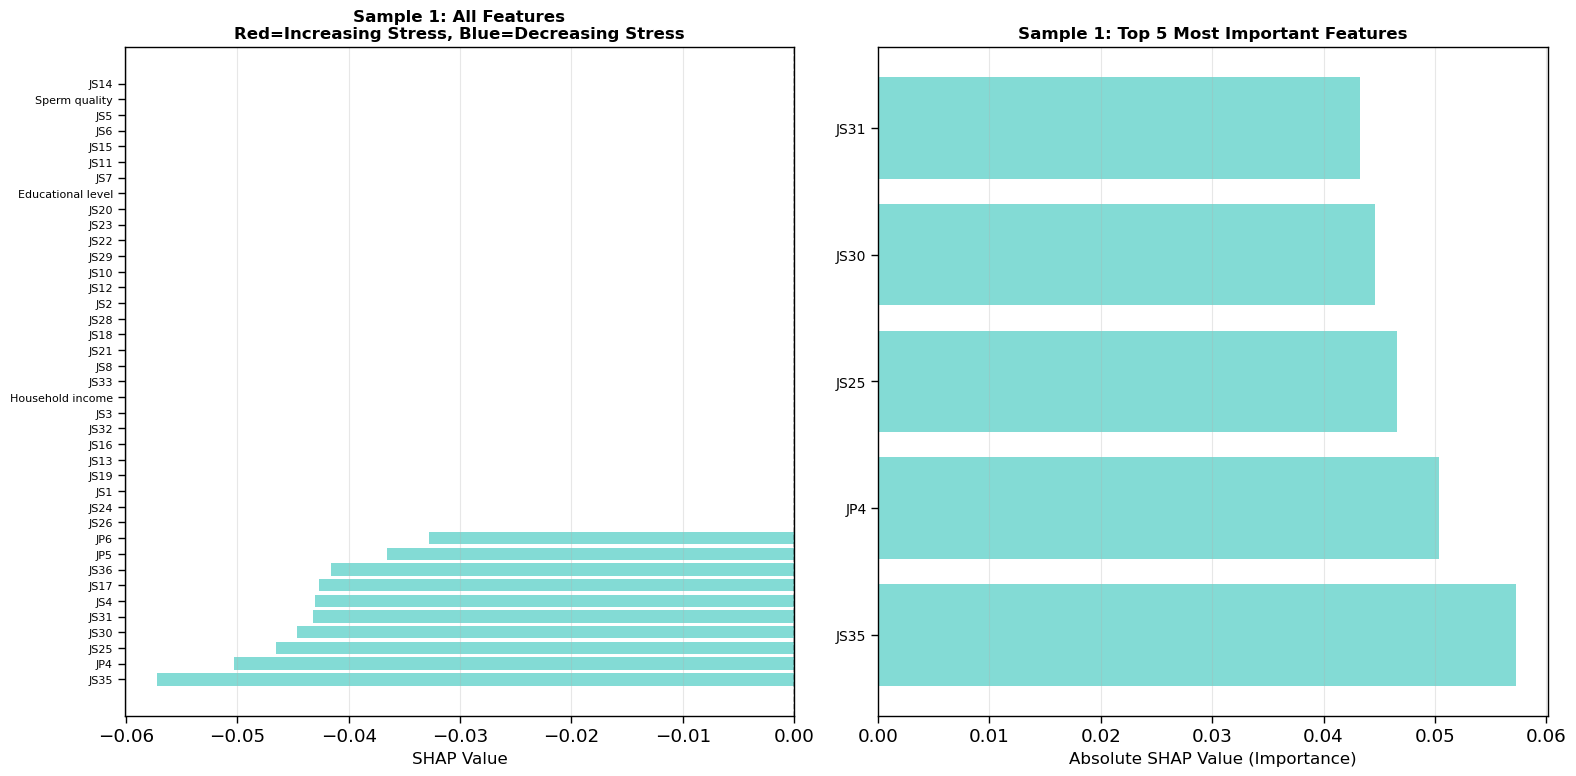

In [76]:
sample_idx = 1

# Figure 생성
fig = plt.figure(figsize=(16, 8))

# 서브플롯 1: SHAP 값 전체 (양수/음수)
ax1 = plt.subplot(1, 2, 1)
colors = ['#FF6B6B' if x > 0 else '#4ECDC4' for x in shap_df['shap_value']]
ax1.barh(range(len(shap_df)), shap_df['shap_value'], color=colors, alpha=0.7)
ax1.set_yticks(range(len(shap_df)))
ax1.set_yticklabels(shap_df['feature'], fontsize=8)
ax1.set_xlabel('SHAP Value', fontsize=12)
ax1.set_title(f'Sample {sample_idx}: All Features\nRed=Increasing Stress, Blue=Decreasing Stress', 
              fontsize=12, fontweight='bold')
ax1.axvline(x=0, color='black', linestyle='--', linewidth=1)
ax1.grid(axis='x', alpha=0.3)

# 서브플롯 2: 절대값 Top 5
ax2 = plt.subplot(1, 2, 2)
top5 = shap_df.head(5)
colors_top = ['#FF6B6B' if x > 0 else '#4ECDC4' for x in top5['shap_value']]
ax2.barh(range(len(top5)), top5['abs_shap'], color=colors_top, alpha=0.7)
ax2.set_yticks(range(len(top5)))
ax2.set_yticklabels(top5['feature'], fontsize=10)
ax2.set_xlabel('Absolute SHAP Value (Importance)', fontsize=12)
ax2.set_title(f'Sample {sample_idx}: Top 5 Most Important Features', 
              fontsize=12, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()